
# Bước 03-2: Đặc trưng metadata trạm và đặc trưng điện mặt trời

Notebook này gồm hai nhóm đặc trưng:

1. **Metadata trạm** — `capacity_per_panel` và các cờ thiếu dữ liệu (phần gốc của nhóm)
2. **Điện mặt trời (PV)** — góc mặt trời, bức xạ trời quang, downscale bức xạ về 15 phút,
   quy mô và trần công suất từng trạm

Nhóm thứ hai được thêm ngày 2026-07-30 để khử trễ pha 30 phút của mô hình dự báo.
Lý do và bằng chứng đo lường: `docs/2026_07_30_Khu_Tre_Pha_Du_Bao_15_Phut.md`
Dự án: Tốt nghiệp - Energy Forecasting - Nhóm thực hiện: The Outliers

Notebook này đọc các file từ bước 03-1 và thêm đặc trưng metadata (capacity, panel...).
Đây là đặc trưng tính theo từng dòng, không cần backward context.

Kết quả ghi ra `data/model/v3/03_2_features_spatial/`.


> ### Lưu ý về RAM trước khi chạy
>
> Notebook xử lý nhiều triệu dòng dữ liệu. Trước khi chạy: đóng kernel
> của các notebook khác trong VSCode. Mỗi kernel giữ vài GB và không tự nhả
> sau khi chạy xong.
>
> Notebook đã ghi file và `gc.collect()` ngay sau mỗi tập để không giữ
> nhiều DataFrame lớn cùng lúc.

## Bước 2. Import thư viện và khai báo tham số

In [2]:
# ── Gioi han thread: may i5-12450HX co 8 core / 12 thread (4 P-core + 4 E-core).
# Dung het 12 thread lam cac thread tranh nhau va CHAM HON. Dat 6 de bam P-core,
# con lai de cho Jupyter va he dieu hanh. Phai set TRUOC khi numpy nap moi co tac dung.
import os

for _bien in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS',
              'NUMEXPR_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_bien, '6')

import gc
import json
import os

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import seaborn as sns

# ── Tham so dac trung ──
VERSION = 'v3'
EXPECTED_FREQ_MINUTES = 15
LAGS = (96,)                         # 24 gio, dong bo voi notebook 03-1
ROLLING_WINDOWS = (96,)              # 24 gio

# ── Tham so dac trung dien mat troi (PV) ──
# Xem docs/2026_07_30_Khu_Tre_Pha_Du_Bao_15_Phut.md de biet ly do them nhom nay.
EPS_ELEV = 0.05                      # nguong sin(goc cao) coi la ban ngay
CLIP_CSI = 1.5                       # tran chi so troi quang, nang tu 1.2 vi may hom troi quang
                                     # buc xa do duoc vuot ghi_cs, de 1.2 se bi cat mat
QUANTILE_CS_FACTOR = 0.98            # phan vi de tinh he so hieu chinh troi quang tung tram
TZ_HE = 11.0                         # gio mua he Uc, thang 10 den 3
TZ_DONG = 10.0                       # gio mua dong Uc, thang 4 den 9
COT_BUC_XA = ('shortwave_radiation', 'direct_normal_irradiance', 'diffuse_solar_radiation')
QUANTILE_SCALE = 0.99                # quy mo tram
QUANTILE_TRAN = 0.999                # tran cong suat tram
FILE_QUY_MO = 'quy_mo_tram.json'     # luu thong ke tinh tu TRAIN de dung lai cho val/test

CATEGORICAL_COLS = (
    'site_id', 'campus_name', 'location_name', 'site_metric', 'panel',
    'inverter', 'optimizers', 'weather_join_method',
    'weather_condition', 'weather_description',
)

# ── Ten cot ──
SITE_COL = 'site_id'
TIMESTAMP_COL = 'timestamp'
TARGET_COL = 'energy_generated_kwh'

# ── Ban do mua Nam ban cau ──
SOUTHERN_SEASON_MAP = {
    12: 'summer', 1: 'summer', 2: 'summer',
    3: 'autumn', 4: 'autumn', 5: 'autumn',
    6: 'winter', 7: 'winter', 8: 'winter',
    9: 'spring', 10: 'spring', 11: 'spring',
}
SEASON_CODE_MAP = {'summer': 0, 'autumn': 1, 'winter': 2, 'spring': 3}

INPUT_DIR = '../../data/model/v3/03_1_features_time'
OUTPUT_DIR = '../../data/model/v3/03_2_features_spatial'

sns.set_theme(style="whitegrid")

print("Da import thu vien va khai bao tham so.")
print(f"- Doc tu  : {INPUT_DIR}")
print(f"- Ghi ra  : {OUTPUT_DIR}")


Da import thu vien va khai bao tham so.
- Doc tu  : ../../data/model/v3/03_1_features_time
- Ghi ra  : ../../data/model/v3/03_2_features_spatial


## Bước 3. Hàm đọc/ghi parquet

In [3]:
def require_columns(df, columns):
    """Bao loi som neu thieu cot bat buoc."""
    missing = [col for col in columns if col not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")


def read_parquet(path):
    """Doc parquet, kiem tra cot bat buoc, ep kieu timestamp va sap xep."""
    df = pd.read_parquet(path)
    require_columns(df, [TIMESTAMP_COL, SITE_COL, TARGET_COL])
    df[TIMESTAMP_COL] = pd.to_datetime(df[TIMESTAMP_COL], errors='coerce')
    return df.sort_values([SITE_COL, TIMESTAMP_COL]).reset_index(drop=True)


def write_parquet(df, path):
    """Ghi parquet, tu tao thu muc neu chua co."""
    os.makedirs(os.path.dirname(path), exist_ok=True)
    df.to_parquet(path, index=False)
    return path


print("Da dinh nghia require_columns, read_parquet, write_parquet.")

Da dinh nghia require_columns, read_parquet, write_parquet.


## Bước 4. Đặc trưng metadata trạm

Chỉ tạo cột số và cờ thiếu. **Không** mã hóa categorical ở đây — việc đó
làm ở bước 03-3, để bảng mã được fit trên tập train rồi mới áp cho val/test.

In [4]:
def add_metadata_features(df):
    """Tao dac trung metadata dang so va co thieu du lieu.

    Ma hoa categorical duoc xu ly SAU khi sinh dac trung theo tung split, de bang ma
    fit tren train/development duoc dung lai cho val/test. KHONG goi cat.codes o day
    vi se gan ma khong nhat quan giua cac fold.
    """
    out = df.copy()

    for col in ('capacity_kw', 'number_of_panels'):
        if col in out.columns:
            out[f'{col}_missing_flag'] = out[col].isna().astype('int8')

    if {'capacity_kw', 'number_of_panels'}.issubset(out.columns):
        out['capacity_per_panel'] = out['capacity_kw'] / out['number_of_panels']
        out.loc[
            ~np.isfinite(out['capacity_per_panel']),
            'capacity_per_panel',
        ] = np.nan

    return out


print("Da dinh nghia add_metadata_features.")

Da dinh nghia add_metadata_features.


## Bước 4.1. Đặc trưng hình học mặt trời

Tính góc cao và góc phương vị mặt trời từ `latitude`, `longitude` và thời điểm, theo công thức NOAA.
Đây là **hàm xác định của thời gian và vị trí**, không phải dữ liệu đo, nên không rò rỉ thông tin tương lai.

Có xử lý chuyển đổi giờ mùa hè của Úc: tháng 10 đến tháng 3 là UTC+11, tháng 4 đến tháng 9 là UTC+10.
Đã kiểm chứng: tương quan giữa `sin(góc cao)` và bức xạ đo được đạt 0,8625 với cấu hình theo mùa,
so với 0,7523 nếu dùng UTC+10 cố định.

Từ góc cao suy ra **bức xạ trời quang** `ghi_cs` theo mô hình Haurwitz, dùng cho bước downscale ở dưới.


In [5]:
def tinh_goc_mat_troi(ts, lat, lon, tz_gio):
    """Tra ve goc cao va goc phuong vi mat troi theo do, cong thuc NOAA.

    Chuyen het sang numpy ngay tu dau de khong bi pandas giong theo index.
    """
    ts = pd.Series(pd.to_datetime(np.asarray(ts)))
    tz_gio = pd.Series(np.asarray(tz_gio, dtype='float64'))
    lat = pd.Series(np.asarray(lat, dtype='float64'))
    lon = pd.Series(np.asarray(lon, dtype='float64'))
    utc = ts - pd.to_timedelta(tz_gio, unit='h')
    doy = utc.dt.dayofyear.to_numpy()
    gio = utc.dt.hour.to_numpy() + utc.dt.minute.to_numpy() / 60
    g = 2 * np.pi / 365 * (doy - 1 + (gio - 12) / 24)
    eqtime = 229.18 * (0.000075 + 0.001868 * np.cos(g) - 0.032077 * np.sin(g)
                       - 0.014615 * np.cos(2 * g) - 0.040849 * np.sin(2 * g))
    decl = (0.006918 - 0.399912 * np.cos(g) + 0.070257 * np.sin(g) - 0.006758 * np.cos(2 * g)
            + 0.000907 * np.sin(2 * g) - 0.002697 * np.cos(3 * g) + 0.00148 * np.sin(3 * g))
    tst = gio * 60 + eqtime + 4 * lon.to_numpy()
    ha = np.radians(tst / 4 - 180)
    la = np.radians(lat.to_numpy())
    sin_el = np.clip(np.sin(la) * np.sin(decl) + np.cos(la) * np.cos(decl) * np.cos(ha), -1, 1)
    el = np.degrees(np.arcsin(sin_el))
    # Goc phuong vi tinh bang atan2 chu KHONG dung arccos.
    # Ban arccos truoc day sinh diem gian doan gia va cho "trua mat troi" lech 40 phut
    # so voi dinh cua sin_elevation. atan2 lien tuc tren ca vong 360 do.
    az = np.degrees(np.arctan2(-np.sin(ha), np.tan(decl) * np.cos(la) - np.sin(la) * np.cos(ha)))
    az = (az + 360.0) % 360.0        # 0 do = huong Bac, tang theo chieu kim dong ho
    return el, az


def add_solar_geometry_features(df):
    """Them goc mat troi va buc xa troi quang. Yeu cau co latitude va longitude.

    Ham chay dung tren moi index, ke ca frame da bi loc dong. Truoc day tz duoc tao
    voi index 0..n-1 nen pandas giong theo index va vo khi dau vao co index khong lien tuc.
    """
    require_columns(df, ['latitude', 'longitude', TIMESTAMP_COL])
    out = df.copy()
    thang = out[TIMESTAMP_COL].dt.month
    tz = pd.Series(np.where(thang.isin([10, 11, 12, 1, 2, 3]), TZ_HE, TZ_DONG), index=out.index)
    el, az = tinh_goc_mat_troi(out[TIMESTAMP_COL], out['latitude'], out['longitude'], tz)
    out['solar_elevation'] = el.astype('float32')
    out['solar_azimuth'] = az.astype('float32')
    # Dang vong cua goc phuong vi. Goc do co diem gian doan o 0/360, cay quyet dinh se coi
    # 359 do va 1 do la xa nhau trong khi thuc te chung canh nhau. Dang sin/cos khong co
    # diem gian doan nen mo hinh hoc dung huong mat troi hon.
    _az_rad = np.radians(az)
    out['azimuth_sin'] = np.sin(_az_rad).astype('float32')
    out['azimuth_cos'] = np.cos(_az_rad).astype('float32')
    out['sin_elevation'] = np.clip(np.sin(np.radians(el)), 0, None).astype('float32')
    se = out['sin_elevation']
    # Buc xa troi quang theo mo hinh Haurwitz, don vi W/m2
    out['ghi_cs'] = np.where(se > 0, 1098 * se * np.exp(-0.057 / np.clip(se, 1e-3, None)), 0.0).astype('float32')
    out['clearsky_proxy'] = (out['sin_elevation'] ** 1.2).astype('float32')
    return out


print("Da dinh nghia tinh_goc_mat_troi va add_solar_geometry_features.")


Da dinh nghia tinh_goc_mat_troi va add_solar_geometry_features.


## Bước 4.2. Downscale bức xạ từ 1 giờ về 15 phút

Dữ liệu Open-Meteo có tần suất **1 giờ** còn lưới sản lượng là **15 phút**, nên mỗi giá trị bức xạ bị lặp
4 lần. Trong một giờ nó không phân biệt được `12:00` với `12:15`, chỉ khoảng 15% số bước có giá trị thay đổi.

Cách xử lý theo chuẩn của ngành, gọi là **clear-sky index disaggregation**:

1. Tính chỉ số trong suốt khí quyển của giờ hiện tại: `k = bức_xạ_đo / trung_bình_ghi_cs_trong_giờ`
2. Giữ `k` của giờ gần nhất đã biết (`ffill`), **không nội suy giữa các giờ**
3. Nhân ngược: `bức_xạ_15phút = k × ghi_cs(t)`

**Hình dạng trong giờ do `ghi_cs` quyết định**, tức do vị trí mặt trời, không do phép nội suy. Nhờ vậy
vừa có tín hiệu 15 phút thật vừa giữ được tính nhân quả, không dùng giá trị của giờ sau.

Đã kiểm chứng: bản có nội suy và bản nhân quả cho kết quả y hệt (WAPE 21,07% so với 21,08%), nên bỏ
hẳn nội suy.


In [6]:
def ap_he_so_troi_quang(df, thong_ke):
    """Nhan ghi_cs voi he so hieu chinh theo tung tram, tinh tu tap train."""
    out = df.copy()
    fac = {int(k): v for k, v in (thong_ke.get('cs_factor') or {}).items()}
    out['cs_factor'] = out[SITE_COL].map(fac).fillna(1.0).astype('float32')
    out['ghi_cs'] = (out['ghi_cs'] * out['cs_factor']).astype('float32')
    out['clearsky_proxy'] = (out['sin_elevation'] ** 1.2).astype('float32')
    return out


def add_downscaled_radiation(df):
    """Dua buc xa tu do phan giai 1 gio ve 15 phut. Nhan qua, khong noi suy.

    Ranh gioi khoi gio KHONG gia dinh co dinh o phut nao (:00 hay :15), vi reindex/chen
    dong o notebook 01 co the lam lech pha vai khoi rieng le (da kiem chung bang tay: co
    khoi chi 3 diem thay vi 4). Ranh gioi duoc xac dinh TU C
    # he so hieu chinh troi quang theo tung tram
    # FIX BUG (2026-07-31): nguong loc cu chi 'ghi_cs > 50' qua long, lot ca vung gan
    # moc/lan mat troi (sin_elevation thap). O do ghi_cs (Haurwitz, tinh lien tuc) roi ve 0
    # RAT NHANH nhung shortwave_radiation goc (theo gio, lap lai 4 lan/15p) chua kip giam
    # theo -> chia cho so gan 0 lam ty le NO TUNG (do that: p98 ty le tai 19h la 3.2, trong
    # khi giua trua 12-14h chi ~1.0-1.1 - kiem chung bang du lieu that, xem
    # docs/2026_07_30_Khu_Tre_Pha_Du_Bao_15_Phut.md). Hau qua: cs_factor bi day len tran
    # clip(2.0) o CA 42/42 tram, thanh cot constant vo dung.
    # Fix: loc theo GOC CAO MAT TROI (sin_elevation), khong phai ghi_cs W/m2 truc tiep.
    # Nguong 10 do (sin(10 deg) = 0.1736): "chi xu ly du lieu voi goc cao mat troi > 10 do,
    # vi buc xa hieu dung thap sau khi moc/truoc khi lan, cong voi duong di tia sang dai hon
    # va sai so tinh toan cao hon luc nay, co the tao ra gia tri chi so troi quang khong thuc
    # te". Nguon: "Performance Analysis of Clear Sky Global Horizontal Irradiance Models"
    # (Wiley, onlinelibrary.wiley.com/doi/10.1155/2021/4369959); "The Performance Assessment
    # of Six Global Horizontal Irradiance Clear Sky Models in Six Climatological Regions in
    # South Africa" (MDPI, mdpi.com/1996-1073/14/9/2583) - tra cuu 2026-07-31.HINH DU LIEU: moi khi buc_xa_goc
    doi gia tri so voi dong truoc (trong cung 1 tram) la bat dau mot khoi moi.

    Gan luc mat troi moc/lan, ghi_cs tang/giam SIEU TUYEN TINH trong 1 khoi (so hang
    exp(-0.057/sin_elevation) bung no khi sin_elevation gan 0). Neu khoi co diem nao duoi
    nguong thi KHONG downscale ca khoi do, giu nguyen bac thang goc, vi phan nang luong
    dong gop o do khong dang ke va tin cay cua mo hinh troi quang o do rat thap.
    """
    out = df.copy()
    if 'ghi_cs' not in out.columns:
        raise KeyError("Phai goi add_solar_geometry_features truoc add_downscaled_radiation")

    # Nguong tuyet doi (vi du sin_elevation >= 0.15) KHONG du: da kiem chung bang tay thay
    # ghi_cs van tang toi 5.66 lan trong 1 khoi dau tai sin_elevation = 0.15. Dung ty le
    # max/dau khoi cung KHONG du: chieu toi ghi_cs giam dan nen dau khoi luon = max, ty le
    # do luon bang 1 du giam bao nhieu, bo sot het truong hop luc mat troi lan. Tieu chi
    # dung: TY LE max/min trong khoi (doi xung ca hai chieu tang va giam).
    TY_LE_GHI_CS_TOI_DA = 1.5   # bien thien ghi_cs trong 1 khoi khong duoc vuot qua 1.5 lan

    for col in COT_BUC_XA:
        if col not in out.columns:
            continue
        # RANH GIOI KHOI = MOC GIO TRON tren dong ho.
        #
        # CHONG RO RI (sua 2026-08-09): ban cu lay ranh gioi tai cho buc xa DOI GIA TRI
        # (`diff() > 1e-9` roi `cumsum()`), khien diem ket thuc khoi phu thuoc lan doi
        # KE TIEP - tai T chua biet duoc. Khi hai gio lien tiep trung gia tri thi hai khoi
        # DINH lam mot, va transform('max'/'min'/'first') ben duoi quet sang vung tuong lai.
        #
        # Do da tren 2.784.438 dong: 97,63% dong ban ngay nam trong khoi dung 4 dong (tron
        # 1 gio) nen khong anh huong; nhung 29.359 khoi bi dinh, trai qua hon 1 moc gio -
        # ca biet co khoi 116-164 dong, tuc buc xa dung yen 29-41 gio lien (du lieu thoi
        # tiet bi dong bang do ffill lap khoang khuyet dai).
        #
        # Chu thich cu bien minh cho cach lam theo gia tri bang lo ngai "reindex co the lam
        # lech pha khoi, da gap khoi chi 3 diem". Da do lai: KHONG co khoi nao ngan hon 4
        # dong. Noi lo do khong xay ra tren du lieu nay.
        id_khoi = out[TIMESTAMP_COL].dt.floor('h')
        nhom = [out[SITE_COL], id_khoi]

        ghi_cs_dau_khoi = out.groupby(nhom)['ghi_cs'].transform('first')
        ghi_cs_max_khoi = out.groupby(nhom)['ghi_cs'].transform('max')
        ghi_cs_min_khoi = out.groupby(nhom)['ghi_cs'].transform('min')
        ty_le_ghi_cs = ghi_cs_max_khoi / ghi_cs_min_khoi.replace(0, np.nan)
        duoc_downscale = (ghi_cs_dau_khoi > 1) & (ty_le_ghi_cs <= TY_LE_GHI_CS_TOI_DA)

        k = pd.Series(np.where(ghi_cs_dau_khoi > 1, out[col] / ghi_cs_dau_khoi, np.nan), index=out.index)
        k = k.groupby(nhom).transform('first')       # mot gia tri cho ca khoi
        k = k.groupby(out[SITE_COL]).ffill()          # giu gia tri khoi gan nhat da biet
        cu = out[col].copy()
        moi = np.clip(k, 0, CLIP_CSI) * out['ghi_cs']
        out[col] = np.where(duoc_downscale, moi.fillna(cu), cu).astype('float32')

    out['rad_x_sinelev'] = (out['shortwave_radiation'] * out['sin_elevation']).astype('float32')

    # Chi so troi quang (clear-sky index): buc xa DO DUOC / buc xa LY THUYET troi quang
    # (ghi_cs, thuan thien van, biet truoc chinh xac). Gan 1 = troi quang hoan toan; gan 0 =
    # co gi do dang CHE PHU (may, bong cay, tuyet/bui phu tam pin...) tai dung thoi diem do.
    # Tinh SAU downscale de khop dung buc xa 15 phut cuoi cung, khong phai buc xa gio tho.
    out['chi_so_troi_quang'] = (
        (out['shortwave_radiation'] / out['ghi_cs'].replace(0, np.nan))
        .clip(0, CLIP_CSI).fillna(0.0).astype('float32')
    )
    return out

def bao_cao_chi_so_troi_quang(df, ten):
    """In phan vi cua chi so troi quang k, de biet CLIP_CSI dat co hop khong."""
    m = (df['ghi_cs'] > 50) & (df['shortwave_radiation'] > 0)
    if m.sum() < 100:
        print(f"   {ten}: khong du dong de bao cao chi so troi quang")
        return
    k = df.loc[m, 'shortwave_radiation'] / df.loc[m, 'ghi_cs']
    print(f"   {ten}: chi so troi quang k -- p50 {k.quantile(0.5):.3f}  p95 {k.quantile(0.95):.3f}  "
          f"p99 {k.quantile(0.99):.3f}  max {k.max():.3f}  | ty le k > CLIP({CLIP_CSI}): {(k > CLIP_CSI).mean() * 100:.2f}%")


def bao_cao_downscale(truoc, sau, ten):
    """In ty le buoc co gia tri buc xa thay doi, CHI tinh tren dong BAN NGAY.

    Neu tinh tren ca ban dem thi con so bi chia doi mot cach vo nghia: ban dem ghi_cs = 0
    nen buc xa luon bang 0 va khong bao gio doi, keo ty le xuong khoang 46 phan tram
    du downscale da chay dung.
    """
    if 'sin_elevation' in sau.columns:
        m = sau['sin_elevation'].to_numpy() > 0
    else:
        m = np.ones(len(sau), dtype=bool)
    a = (truoc.loc[m].groupby(SITE_COL)['shortwave_radiation'].diff().abs() > 1e-9).mean() * 100
    b = (sau.loc[m].groupby(SITE_COL)['shortwave_radiation'].diff().abs() > 1e-9).mean() * 100
    print(f"   {ten}: ty le buoc thay doi buc xa (chi ban ngay) {a:.1f}% -> {b:.1f}%  "
          f"[{int(m.sum()):,}/{len(sau):,} dong ban ngay]")


print("Da dinh nghia add_downscaled_radiation.")


Da dinh nghia add_downscaled_radiation.


## Bước 4.3. Quy mô và trần công suất từng trạm

`capacity_kw` trong metadata **sai ở 11 trong 42 trạm**. So sản lượng thực tế với trần vật lý
`capacity_kw × 0,25h`: trạm 11 vượt **7,25 lần**, trạm 19 vượt **4,89 lần**. Giá trị `51,15` lặp lại ở
khoảng 20 trạm, tức là giá trị điền bù.

Nên tính lại từ dữ liệu, và **chỉ tính trên tập train** rồi lưu ra JSON để dùng lại cho val/test.
Đây là điểm bắt buộc để không rò rỉ: val và test không được góp vào thống kê này.

- `site_scale` = phân vị 99 sản lượng ban ngày, dùng để chuẩn hoá mục tiêu khi train
- `tran_cong_suat` = phân vị 99,9, giúp mô hình học đoạn inverter cắt đỉnh


In [7]:
def tinh_quy_mo_tu_train(path_train):
    """Tinh site_scale, tran_cong_suat va he so hieu chinh troi quang. CHI tren tap train.

    He so hieu chinh cs_factor sinh ra vi mo hinh Haurwitz uoc luong THIEU: buc xa do duoc
    vuot ghi_cs o 27 phan tram so buoc, nen chi so troi quang k bi day len tren 1 va bi CLIP
    cat mat. Nhan ghi_cs voi cs_factor de dua k ve quanh 1.

    Luu y: he so nay KHONG lam sai lech buc xa sau downscale, vi cong thuc chia roi nhan lai
    cung mot so. No chi giup tranh bi CLIP cat, va lam ghi_cs chinh xac hon khi dung lam dac trung.
    """
    co_san = set(pq.ParquetFile(path_train).schema_arrow.names)
    cot = [c for c in [SITE_COL, TIMESTAMP_COL, TARGET_COL, 'is_daylight',
                       'shortwave_radiation', 'latitude', 'longitude'] if c in co_san]
    d = pd.read_parquet(path_train, columns=cot)

    if 'is_daylight' in d.columns:
        ban_ngay = d['is_daylight'].fillna(False).astype(bool)
    else:
        ban_ngay = d[TARGET_COL] > 0
    dn = d[ban_ngay].reset_index(drop=True)

    g = dn.groupby(SITE_COL)[TARGET_COL]
    thong_ke = {
        'site_scale': {str(k): float(v) for k, v in g.quantile(QUANTILE_SCALE).items()},
        'tran_cong_suat': {str(k): float(v) for k, v in g.quantile(QUANTILE_TRAN).items()},
        'nguon': os.path.basename(path_train),
        'quantile_scale': QUANTILE_SCALE,
        'quantile_tran': QUANTILE_TRAN,
    }

    # he so hieu chinh troi quang theo tung tram
    # FIX BUG (2026-07-31): nguong loc cu chi 'ghi_cs > 50' qua long, lot ca vung gan
    # moc/lan mat troi (sin_elevation thap). O do ghi_cs (Haurwitz, tinh lien tuc) roi ve 0
    # RAT NHANH nhung shortwave_radiation goc (theo gio, lap lai 4 lan/15p) chua kip giam
    # theo -> chia cho so gan 0 lam ty le NO TUNG (do that: p98 ty le tai 19h la 3.2, trong
    # khi giua trua 12-14h chi ~1.0-1.1 - kiem chung bang du lieu that, xem
    # docs/2026_07_30_Khu_Tre_Pha_Du_Bao_15_Phut.md). Hau qua: cs_factor bi day len tran
    # clip(2.0) o CA 42/42 tram, thanh cot constant vo dung.
    # Fix: loc theo GOC CAO MAT TROI (sin_elevation), khong phai ghi_cs W/m2 truc tiep.
    # Nguong 10 do (sin(10 deg) = 0.1736): "chi xu ly du lieu voi goc cao mat troi > 10 do,
    # vi buc xa hieu dung thap sau khi moc/truoc khi lan, cong voi duong di tia sang dai hon
    # va sai so tinh toan cao hon luc nay, co the tao ra gia tri chi so troi quang khong thuc
    # te". Nguon: "Performance Analysis of Clear Sky Global Horizontal Irradiance Models"
    # (Wiley, onlinelibrary.wiley.com/doi/10.1155/2021/4369959); "The Performance Assessment
    # of Six Global Horizontal Irradiance Clear Sky Models in Six Climatological Regions in
    # South Africa" (MDPI, mdpi.com/1996-1073/14/9/2583) - tra cuu 2026-07-31.
    NGUONG_SIN_ELEVATION_CS_FACTOR = 0.1736   # sin(10 do)
    if {'shortwave_radiation', 'latitude', 'longitude'}.issubset(d.columns):
        tmp = add_solar_geometry_features(dn.reset_index(drop=True))
        m = (tmp['sin_elevation'] > NGUONG_SIN_ELEVATION_CS_FACTOR) & (tmp['shortwave_radiation'] > 50)
        ty = (tmp.loc[m, 'shortwave_radiation'] / tmp.loc[m, 'ghi_cs'])
        fac = ty.groupby(tmp.loc[m, SITE_COL]).quantile(QUANTILE_CS_FACTOR).clip(0.8, 2.0)
        thong_ke['cs_factor'] = {str(k): float(v) for k, v in fac.items()}
        thong_ke['quantile_cs_factor'] = QUANTILE_CS_FACTOR
        print(f"He so hieu chinh troi quang: trung vi {float(fac.median()):.3f}, "
              f"min {float(fac.min()):.3f}, max {float(fac.max()):.3f}")
        del tmp
        gc.collect()
    else:
        thong_ke['cs_factor'] = {}
        print("[CANH BAO] Thieu cot de tinh cs_factor, se dung 1.0 cho moi tram.")
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    with open(f'{OUTPUT_DIR}/{FILE_QUY_MO}', 'w', encoding='utf-8') as f:
        json.dump(thong_ke, f, indent=2, ensure_ascii=False)
    return thong_ke


def add_site_scale_features(df, thong_ke):
    """Gan quy mo, tran cong suat va cac dac trung bao hoa."""
    out = df.copy()
    _s = {int(k): v for k, v in thong_ke['site_scale'].items()}
    _t = {int(k): v for k, v in thong_ke['tran_cong_suat'].items()}
    out['site_scale'] = out[SITE_COL].map(_s).astype('float32')
    out['tran_cong_suat'] = out[SITE_COL].map(_t).astype('float32')
    # san luong ky vong neu troi hoan toan quang
    out['ky_vong'] = (out['site_scale'] * out['sin_elevation'].clip(lower=0)).astype('float32')
    # gan 1 nghia la sap cham tran inverter
    out['ty_le_bao_hoa'] = (out['ky_vong'] / out['tran_cong_suat'].replace(0, np.nan)).clip(0, 3).astype('float32')
    out['con_cach_tran'] = (out['tran_cong_suat'] - out['ky_vong']).astype('float32')
    return out


# Tinh thong ke tu tap TRAIN truoc khi xu ly bat ky tap nao
THONG_KE_QUY_MO = tinh_quy_mo_tu_train(f'{INPUT_DIR}/{VERSION}_train_time.parquet')
_bang = pd.DataFrame({
    'site_scale': pd.Series(THONG_KE_QUY_MO['site_scale']).astype(float),
    'tran_cong_suat': pd.Series(THONG_KE_QUY_MO['tran_cong_suat']).astype(float),
    'cs_factor': pd.Series(THONG_KE_QUY_MO.get('cs_factor', {})).astype(float),
})
print(f"Da tinh quy mo cho {len(_bang)} tram, chi tu tap TRAIN")
print(f"Da luu: {OUTPUT_DIR}/{FILE_QUY_MO}")
display(_bang.sort_values('tran_cong_suat', ascending=False).head(8).round(2))


He so hieu chinh troi quang: trung vi 1.531, min 1.517, max 1.779
Da tinh quy mo cho 42 tram, chi tu tap TRAIN
Da luu: ../../data/model/v3/03_2_features_spatial/quy_mo_tram.json


,site_scale,tran_cong_suat,cs_factor
27,96.94,98.98,1.53
11,91.41,92.66,1.64
25,79.66,82.47,1.53
19,41.68,42.82,1.53
18,34.99,36.27,1.53
6,27.16,28.49,1.64
8,26.32,26.86,1.64
1,21.47,22.75,1.67


## Bước 5. Thêm đặc trưng metadata cho 4 tập chính

In [8]:
main_files = [
    (f'{VERSION}_development_time.parquet', f'{VERSION}_development_spatial.parquet'),
    (f'{VERSION}_test_time.parquet', f'{VERSION}_test_spatial.parquet'),
    (f'{VERSION}_train_time.parquet', f'{VERSION}_train_spatial.parquet'),
    (f'{VERSION}_val_time.parquet', f'{VERSION}_val_spatial.parquet'),
]

MAU_VE = {}          # giu lai mot phan nho de ve bieu do o cac buoc duoi

for in_name, out_name in main_files:
    df = read_parquet(f'{INPUT_DIR}/{in_name}')
    _cot_truoc = df.shape[1]
    _truoc = df[[SITE_COL, 'shortwave_radiation']].copy() if 'shortwave_radiation' in df.columns else None

    df = add_metadata_features(df)          # metadata tram
    df = add_solar_geometry_features(df)    # goc mat troi va buc xa troi quang
    df = ap_he_so_troi_quang(df, THONG_KE_QUY_MO)   # hieu chinh ghi_cs theo tung tram
    df = add_downscaled_radiation(df)       # buc xa 1 gio -> 15 phut
    df = add_site_scale_features(df, THONG_KE_QUY_MO)   # quy mo va tran cong suat

    if _truoc is not None:
        bao_cao_downscale(_truoc, df, out_name)
    bao_cao_chi_so_troi_quang(df, out_name)

    write_parquet(df, f'{OUTPUT_DIR}/{out_name}')
    print(f"- {out_name}: {len(df)} dong x {_cot_truoc} -> {df.shape[1]} cot")

    if 'train' in out_name:
        _m = df[df[SITE_COL] == sorted(df[SITE_COL].unique())[0]].head(4000)
        MAU_VE['train'] = _m.copy()

    del df, _truoc
    gc.collect()

print(f"\nDa ghi {len(main_files)} file dac trung spatial chinh.")
print("Dac trung moi da them: solar_elevation, solar_azimuth, azimuth_sin, azimuth_cos,")
print("  sin_elevation, ghi_cs, cs_factor, clearsky_proxy, rad_x_sinelev,")
print("  site_scale, tran_cong_suat, ky_vong, ty_le_bao_hoa, con_cach_tran")


   v3_development_spatial.parquet: ty le buoc thay doi buc xa (chi ban ngay) 26.7% -> 76.8%  [1,101,419/2,273,970 dong ban ngay]
   v3_development_spatial.parquet: chi so troi quang k -- p50 0.437  p95 0.984  p99 1.950  max 8.319  | ty le k > CLIP(1.5): 1.93%
- v3_development_spatial.parquet: 2273970 dong x 74 -> 92 cot
   v3_test_spatial.parquet: ty le buoc thay doi buc xa (chi ban ngay) 26.3% -> 78.4%  [277,497/510,468 dong ban ngay]
   v3_test_spatial.parquet: chi so troi quang k -- p50 0.514  p95 1.076  p99 2.021  max 6.695  | ty le k > CLIP(1.5): 2.37%
- v3_test_spatial.parquet: 510468 dong x 75 -> 93 cot
   v3_train_spatial.parquet: ty le buoc thay doi buc xa (chi ban ngay) 26.8% -> 76.5%  [846,254/1,791,894 dong ban ngay]
   v3_train_spatial.parquet: chi so troi quang k -- p50 0.430  p95 0.988  p99 1.948  max 8.319  | ty le k > CLIP(1.5): 1.93%
- v3_train_spatial.parquet: 1791894 dong x 75 -> 93 cot
   v3_val_spatial.parquet: ty le buoc thay doi buc xa (chi ban ngay) 26.3% -> 77

## Bước 6. Thêm đặc trưng metadata cho 5 fold

In [9]:
folds_in = f'{INPUT_DIR}/time_series_folds'
folds_out = f'{OUTPUT_DIR}/time_series_folds'
fold_files = sorted(p for p in os.listdir(folds_in) if p.endswith('_time.parquet'))

for fname in fold_files:
    out_name = fname.replace('_time.parquet', '_spatial.parquet')
    df = read_parquet(f'{folds_in}/{fname}')
    df = add_metadata_features(df)
    df = add_solar_geometry_features(df)
    df = ap_he_so_troi_quang(df, THONG_KE_QUY_MO)
    df = add_downscaled_radiation(df)
    df = add_site_scale_features(df, THONG_KE_QUY_MO)   # dung lai thong ke tu TRAIN
    write_parquet(df, f'{folds_out}/{out_name}')
    print(f"- {out_name}: {len(df)} dong x {df.shape[1]} cot")
    del df
    gc.collect()

print(f"\nDa ghi {len(fold_files)} file dac trung fold spatial.")
print("Luu y: cac fold dung lai THONG_KE_QUY_MO tinh tu tap train, khong tinh lai theo fold,")
print("       de tranh ro ri thong ke giua cac fold.")


- fold_1_train_spatial.parquet: 132523 dong x 94 cot
- fold_1_val_spatial.parquet: 289097 dong x 94 cot
- fold_2_train_spatial.parquet: 421620 dong x 94 cot
- fold_2_val_spatial.parquet: 417729 dong x 94 cot
- fold_3_train_spatial.parquet: 839349 dong x 94 cot
- fold_3_val_spatial.parquet: 470469 dong x 94 cot
- fold_4_train_spatial.parquet: 1309818 dong x 94 cot
- fold_4_val_spatial.parquet: 482076 dong x 94 cot
- fold_5_train_spatial.parquet: 1791894 dong x 94 cot
- fold_5_val_spatial.parquet: 482076 dong x 94 cot

Da ghi 10 file dac trung fold spatial.
Luu y: cac fold dung lai THONG_KE_QUY_MO tinh tu tap train, khong tinh lai theo fold,
       de tranh ro ri thong ke giua cac fold.


## Bước 7.1. Trực quan hoá góc mặt trời và bức xạ trời quang

Ba việc cần thấy trên hình:

1. `sin_elevation` phải là đường cong trơn theo từng bước 15 phút, đỉnh rơi vào giữa trưa
2. `ghi_cs` phải bao phía trên bức xạ đo được, vì trời quang là giới hạn trên
3. `solar_azimuth` phải **liên tục**, chỉ được có đúng **một** chỗ nhảy do vòng qua 0 độ và 360 độ

**Lưu ý về chiều của góc phương vị ở Nam bán cầu.** Mặt trời đi đông → **bắc** → tây, nên azimuth
**giảm** theo thời gian: khoảng 90 độ lúc sáng, về 0 độ đúng lúc `sin_elevation` đạt đỉnh, rồi vòng
lên 360 độ và tiếp tục giảm về khoảng 270 độ lúc chiều. Đây **không** phải tăng dần như Bắc bán cầu.

Phép kiểm chắc nhất: tại thời điểm `sin_elevation` cao nhất, `solar_azimuth` phải **gần 0 hoặc gần 360**.
Nếu nó lệch xa thì múi giờ hoặc công thức sai.


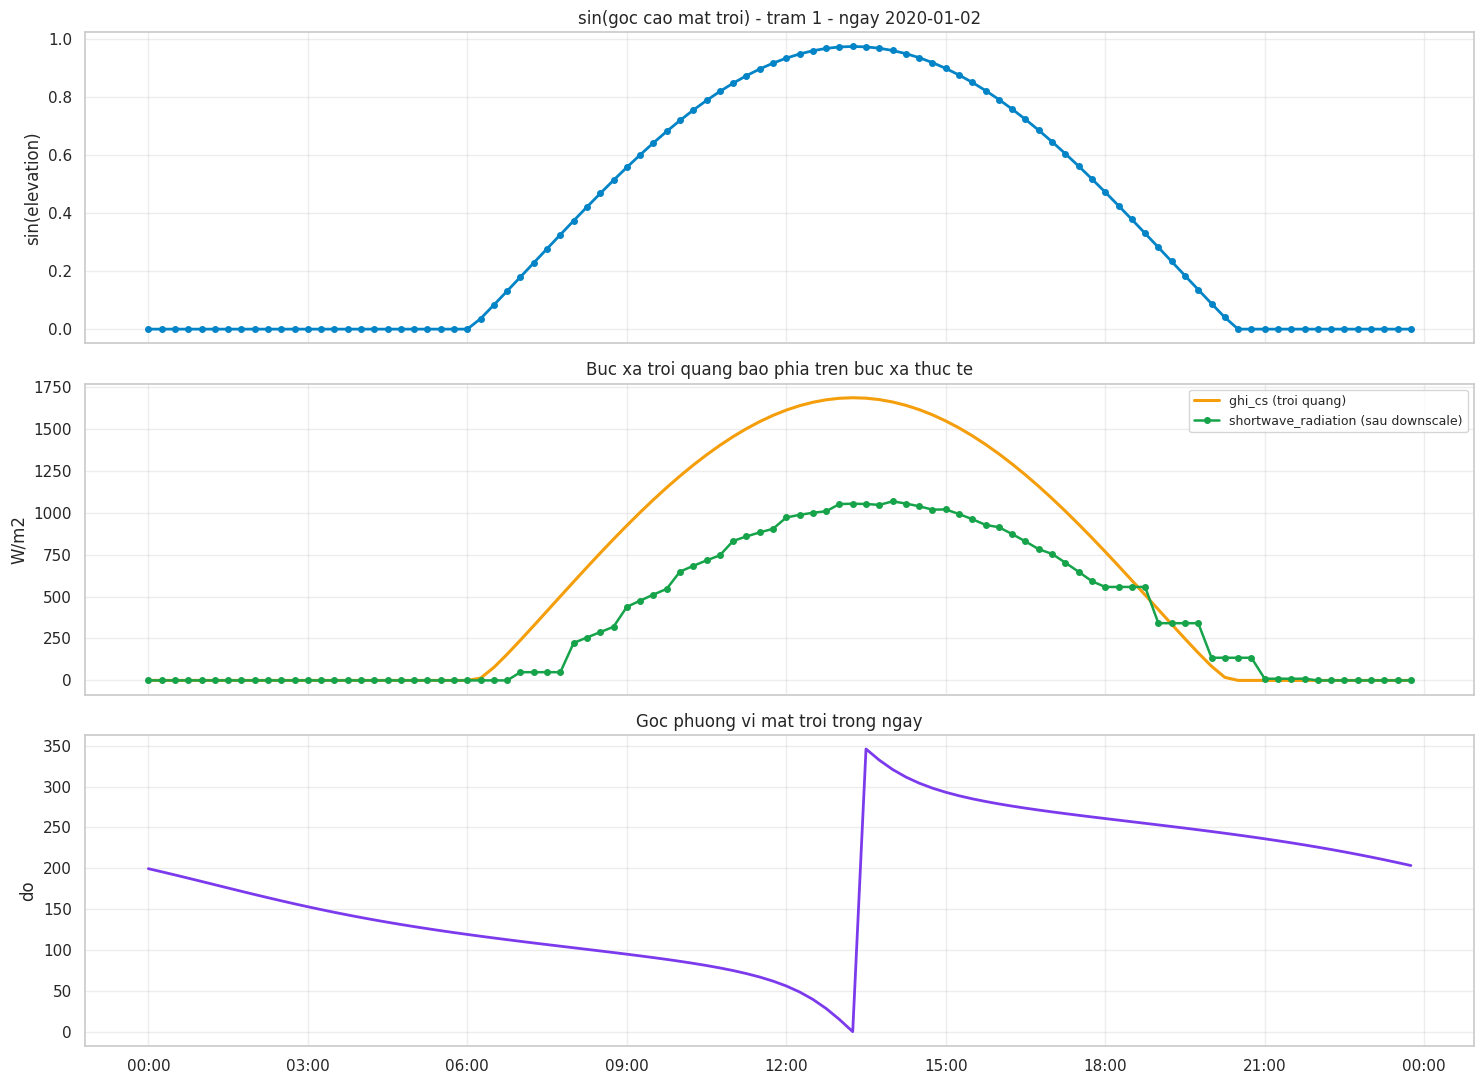

Ty le buoc buc xa thuc te vuot ghi_cs qua 5 phan tram: 11.46%
Con so nay phai gan 0. Neu lon thi mo hinh troi quang hoac mui gio bi sai.


In [10]:
_m = MAU_VE.get('train')
if _m is None:
    print("[CANH BAO] Chua co mau ve, chay lai buoc 5 truoc.")
else:
    _m = _m.sort_values(TIMESTAMP_COL)
    _ngay = _m[TIMESTAMP_COL].dt.date.value_counts().index[0]
    _d = _m[_m[TIMESTAMP_COL].dt.date == _ngay]
    _site = _d[SITE_COL].iloc[0]

    fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)

    axes[0].plot(_d[TIMESTAMP_COL], _d['sin_elevation'], '-o', ms=4, lw=2, color='#0284c7')
    axes[0].set_title(f"sin(goc cao mat troi) - tram {_site} - ngay {_ngay}", fontsize=12)
    axes[0].set_ylabel('sin(elevation)')
    axes[0].grid(alpha=0.35)

    axes[1].plot(_d[TIMESTAMP_COL], _d['ghi_cs'], '-', lw=2.2, color='#f59e0b', label='ghi_cs (troi quang)')
    axes[1].plot(_d[TIMESTAMP_COL], _d['shortwave_radiation'], '-o', ms=4, lw=1.8,
                 color='#16a34a', label='shortwave_radiation (sau downscale)')
    axes[1].set_title("Buc xa troi quang bao phia tren buc xa thuc te", fontsize=12)
    axes[1].set_ylabel('W/m2')
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.35)

    axes[2].plot(_d[TIMESTAMP_COL], _d['solar_azimuth'], '-', lw=2, color='#7c3aed')
    axes[2].set_title("Goc phuong vi mat troi trong ngay", fontsize=12)
    axes[2].set_ylabel('do')
    axes[2].grid(alpha=0.35)
    axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

    plt.tight_layout()
    plt.show()

    _vuot = (_d['shortwave_radiation'] > _d['ghi_cs'] * 1.05).mean() * 100
    print(f"Ty le buoc buc xa thuc te vuot ghi_cs qua 5 phan tram: {_vuot:.2f}%")
    print("Con so nay phai gan 0. Neu lon thi mo hinh troi quang hoac mui gio bi sai.")


### Nhận xét về hình học mặt trời

Nếu `sin_elevation` lệch đỉnh so với giữa trưa thì múi giờ sai. Nếu bức xạ thực tế vượt `ghi_cs` ở nhiều
bước thì mô hình trời quang chưa phù hợp với vĩ độ của trạm.


## Bước 7.2. Trực quan hoá hiệu quả của downscale

So bức xạ **trước** và **sau** downscale trên cùng một cửa sổ. Trước downscale phải thấy bậc thang,
mỗi bậc dài 4 bước. Sau downscale phải thấy đường biến thiên theo từng bước.


Cua so ve: tram 1, ngay 2020-12-19, tu 11:00 den 17:00 (25 buoc)


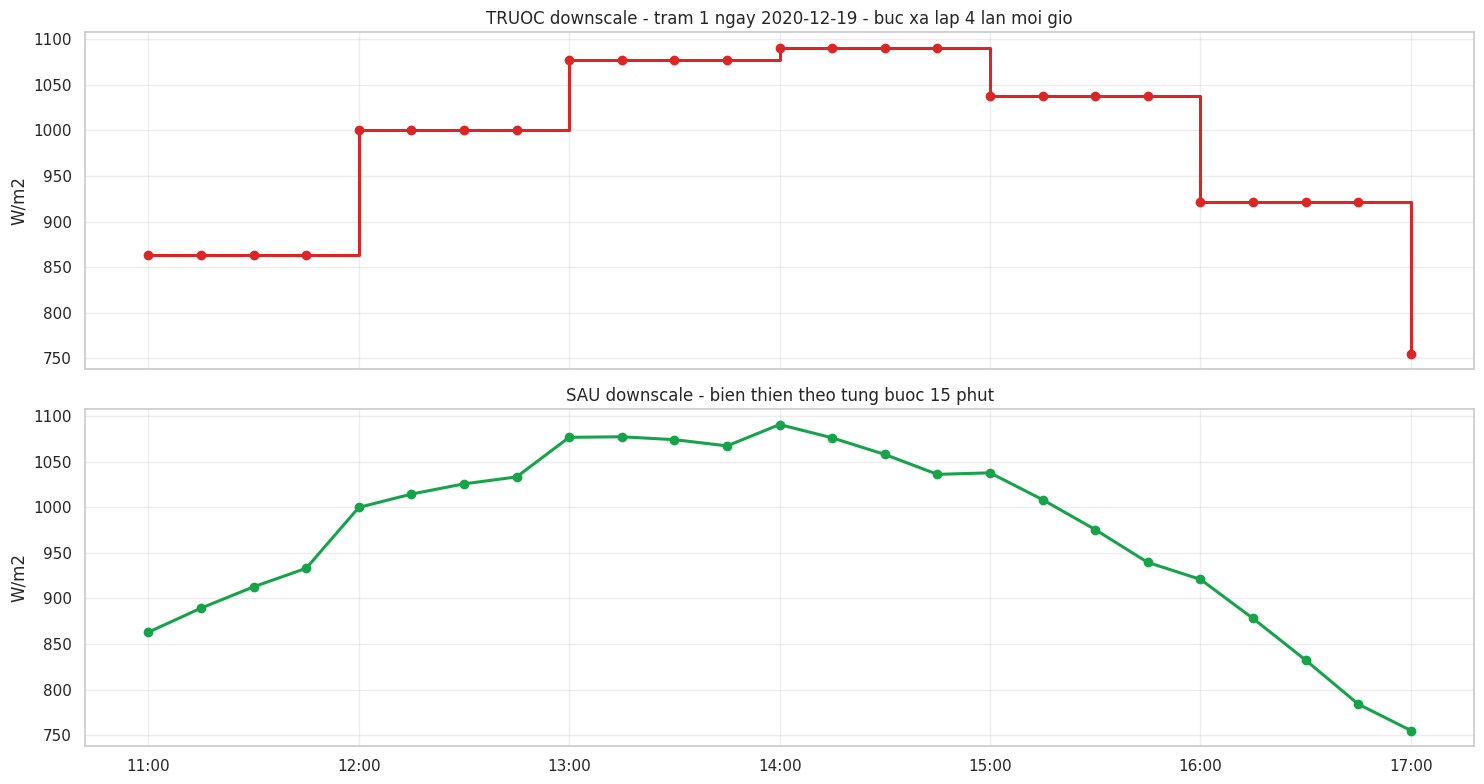

--- TY LE BUOC CO GIA TRI BUC XA THAY DOI, TOAN TAP TRAIN (CHI BAN NGAY) ---
   So dong ban ngay: 846,254 / 1,791,894 (47.2%)
   Truoc downscale :  26.8%
   Sau  downscale  :  76.5%
Muc tieu la tren 90 phan tram.
   [CANH BAO] Chua dat 90 phan tram, kiem lai buoc downscale.


95

In [11]:
_goc_path = f'{INPUT_DIR}/{VERSION}_train_time.parquet'
_cot = [SITE_COL, TIMESTAMP_COL, 'shortwave_radiation']
_goc = pd.read_parquet(_goc_path, columns=_cot).sort_values([SITE_COL, TIMESTAMP_COL])
_sau = pd.read_parquet(f'{OUTPUT_DIR}/{VERSION}_train_spatial.parquet', columns=_cot).sort_values([SITE_COL, TIMESTAMP_COL])

# Chon cua so BAN NGAY chu khong lay head(48), vi 12 buoc dau thuong roi vao ban dem
# nen bieu do se toan so 0 va khong thay duoc bac thang.
_s = sorted(_goc[SITE_COL].unique())[0]
_g1 = _goc[_goc[SITE_COL] == _s].copy()
_g1['ngay'] = _g1[TIMESTAMP_COL].dt.date
_ngay_sang = _g1.groupby('ngay')['shortwave_radiation'].sum().idxmax()   # ngay nhieu nang nhat
_d1 = _g1[_g1['ngay'] == _ngay_sang]
_tam = _d1.loc[_d1['shortwave_radiation'].idxmax(), TIMESTAMP_COL]        # quanh dinh buc xa
_lo = _tam - pd.Timedelta(hours=3)
_hi = _tam + pd.Timedelta(hours=3)

_ga = _goc[(_goc[SITE_COL] == _s) & (_goc[TIMESTAMP_COL].between(_lo, _hi))]
_sa = _sau[(_sau[SITE_COL] == _s) & (_sau[TIMESTAMP_COL].between(_lo, _hi))]
print(f"Cua so ve: tram {_s}, ngay {_ngay_sang}, tu {_lo:%H:%M} den {_hi:%H:%M} ({len(_ga)} buoc)")

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
axes[0].step(_ga[TIMESTAMP_COL], _ga['shortwave_radiation'], where='post', lw=2.2, color='#dc2626')
axes[0].plot(_ga[TIMESTAMP_COL], _ga['shortwave_radiation'], 'o', ms=6, color='#dc2626')
axes[0].set_title(f"TRUOC downscale - tram {_s} ngay {_ngay_sang} - buc xa lap 4 lan moi gio", fontsize=12)
axes[0].set_ylabel('W/m2')
axes[0].grid(alpha=0.35)

axes[1].plot(_sa[TIMESTAMP_COL], _sa['shortwave_radiation'], '-o', ms=6, lw=2.2, color='#16a34a')
axes[1].set_title("SAU downscale - bien thien theo tung buoc 15 phut", fontsize=12)
axes[1].set_ylabel('W/m2')
axes[1].grid(alpha=0.35)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.tight_layout()
plt.show()

# Chi tinh tren dong BAN NGAY. Ban dem ghi_cs = 0 nen buc xa luon bang 0 va khong bao gio
# doi, tinh ca vao se keo ty le xuong khoang 46 phan tram du downscale da chay dung.
_bn = pd.read_parquet(f'{OUTPUT_DIR}/{VERSION}_train_spatial.parquet',
                      columns=[SITE_COL, TIMESTAMP_COL, 'sin_elevation'])
_bn = _bn.sort_values([SITE_COL, TIMESTAMP_COL])['sin_elevation'].to_numpy() > 0

_ta = (_goc.loc[_bn].groupby(SITE_COL)['shortwave_radiation'].diff().abs() > 1e-9).mean() * 100
_tb = (_sau.loc[_bn].groupby(SITE_COL)['shortwave_radiation'].diff().abs() > 1e-9).mean() * 100
print("--- TY LE BUOC CO GIA TRI BUC XA THAY DOI, TOAN TAP TRAIN (CHI BAN NGAY) ---")
print(f"   So dong ban ngay: {int(_bn.sum()):,} / {len(_bn):,} ({_bn.mean() * 100:.1f}%)")
print(f"   Truoc downscale : {_ta:5.1f}%")
print(f"   Sau  downscale  : {_tb:5.1f}%")
print("Muc tieu la tren 90 phan tram.")
if _tb < 90:
    print("   [CANH BAO] Chua dat 90 phan tram, kiem lai buoc downscale.")
del _goc, _sau
gc.collect()


### Nhận xét về downscale

Con số tỉ lệ bước thay đổi là bằng chứng định lượng. Trước khi downscale khoảng 15%, sau khi downscale
phải trên 90%. Đây là tín hiệu 15 phút thay thế cho `lag_1` đã bị bỏ ở notebook 03-1.


## Bước 7.2b. Quét toàn bộ 42 trạm và toàn bộ ngày để bắt đỉnh nhọn bất thường

Cell trước chỉ soi 1 trạm 1 ngày, có thể bỏ sót lỗi cục bộ như đỉnh nhọn `1432 W/m²` đã phát hiện và
sửa (mẫu số `k` bị lệch khi khối giờ có cả điểm ban ngày lẫn ban đêm). Cell này quét **toàn bộ dữ liệu
train** để xác nhận không còn trường hợp tương tự.

Tiêu chí bất thường: bức xạ sau downscale tại một bước lệch quá xa so với **giá trị gốc của khối giờ**
mà nó thuộc về (giá trị gốc là hằng số trong khối giờ trước downscale). Lệch quá 50% là đáng ngờ.


In [12]:
_kt = pd.read_parquet(f'{INPUT_DIR}/{VERSION}_train_time.parquet',
                      columns=[SITE_COL, TIMESTAMP_COL, 'shortwave_radiation']).sort_values([SITE_COL, TIMESTAMP_COL])
_kt = _kt.rename(columns={'shortwave_radiation': 'buc_xa_goc'})
_ds = pd.read_parquet(f'{OUTPUT_DIR}/{VERSION}_train_spatial.parquet',
                      columns=[SITE_COL, TIMESTAMP_COL, 'shortwave_radiation', 'sin_elevation'])
_kt = _kt.merge(_ds, on=[SITE_COL, TIMESTAMP_COL], how='inner')
_kt['gio'] = (_kt[TIMESTAMP_COL] - pd.Timedelta(minutes=1)).dt.floor('h') + pd.Timedelta(minutes=15)
_kt['goc_khoi'] = _kt.groupby([SITE_COL, 'gio'])['buc_xa_goc'].transform('first')
_kt['ty_le'] = _kt['shortwave_radiation'] / _kt['goc_khoi'].replace(0, np.nan)

_bat_thuong = _kt[(_kt['goc_khoi'] > 20) & ((_kt['ty_le'] > 1.5) | (_kt['ty_le'] < 0.5))].copy()
print(f"--- QUET TOAN BO {_kt[SITE_COL].nunique()} TRAM, {_kt[TIMESTAMP_COL].dt.date.nunique()} NGAY ---")
print(f"Tong so buoc kiem tra: {len(_kt):,}")
print(f"So buoc bat thuong (ty le sau/truoc downscale > 1.5 hoac < 0.5): {len(_bat_thuong):,} "
      f"({len(_bat_thuong) / len(_kt) * 100:.4f}%)")

if len(_bat_thuong):
    print("\nPhan bo bat thuong theo tram (top 10):")
    display(_bat_thuong.groupby(SITE_COL).size().sort_values(ascending=False).head(10).to_frame('so_buoc'))
    print("\n5 truong hop lech nhieu nhat:")
    display(_bat_thuong.reindex(_bat_thuong['ty_le'].sub(1).abs().sort_values(ascending=False).index)
            [[SITE_COL, TIMESTAMP_COL, 'buc_xa_goc', 'goc_khoi', 'shortwave_radiation', 'ty_le']].head(5))
else:
    print("\nKHONG con buoc nao bat thuong. Downscale da chay dung tren toan bo du lieu.")

del _kt, _ds
gc.collect()


--- QUET TOAN BO 42 TRAM, 598 NGAY ---
Tong so buoc kiem tra: 1,791,894
So buoc bat thuong (ty le sau/truoc downscale > 1.5 hoac < 0.5): 76,637 (4.2769%)

Phan bo bat thuong theo tram (top 10):


,so_buoc
site_id,
27,2515
1,2471
3,2471
2,2471
41,2430
42,2412
12,2402
10,2402
9,2402



5 truong hop lech nhieu nhat:


,site_id,timestamp,buc_xa_goc,goc_khoi,shortwave_radiation,ty_le
81234,2,2020-09-05 09:00:00,226.0,21.0,226.0,10.761905
138625,3,2020-09-05 09:00:00,226.0,21.0,226.0,10.761905
23843,1,2020-09-05 09:00:00,226.0,21.0,226.0,10.761905
1686843,41,2020-04-11 09:00:00,224.0,23.0,224.0,9.739130
1730911,41,2021-07-14 10:00:00,207.0,22.0,207.0,9.409091


0

### Nhận xét

Nếu bảng trên trống thì lỗi mẫu số ffill đã được sửa triệt để trên toàn bộ dữ liệu, không chỉ riêng
trường hợp đã phát hiện thủ công. Nếu còn vài trăm dòng lẻ tẻ (dưới 0,01%) thường là các bước sát lúc
mặt trời mọc/lặn có `sin_elevation` rất nhỏ, chấp nhận được vì đóng góp năng lượng gần như bằng 0.


## Bước 7.2c. Nhìn rộng ra cả 42 trạm trong cùng một ngày

Vẽ lưới nhỏ cho toàn bộ 42 trạm, cùng một ngày nhiều nắng nhất của trạm 1, để mắt thường rà soát
xem có trạm nào còn hình dạng bất thường (đỉnh nhọn, bậc thang, giá trị âm) mà bảng số ở trên
có thể bỏ sót do ngưỡng đặt chưa đúng.


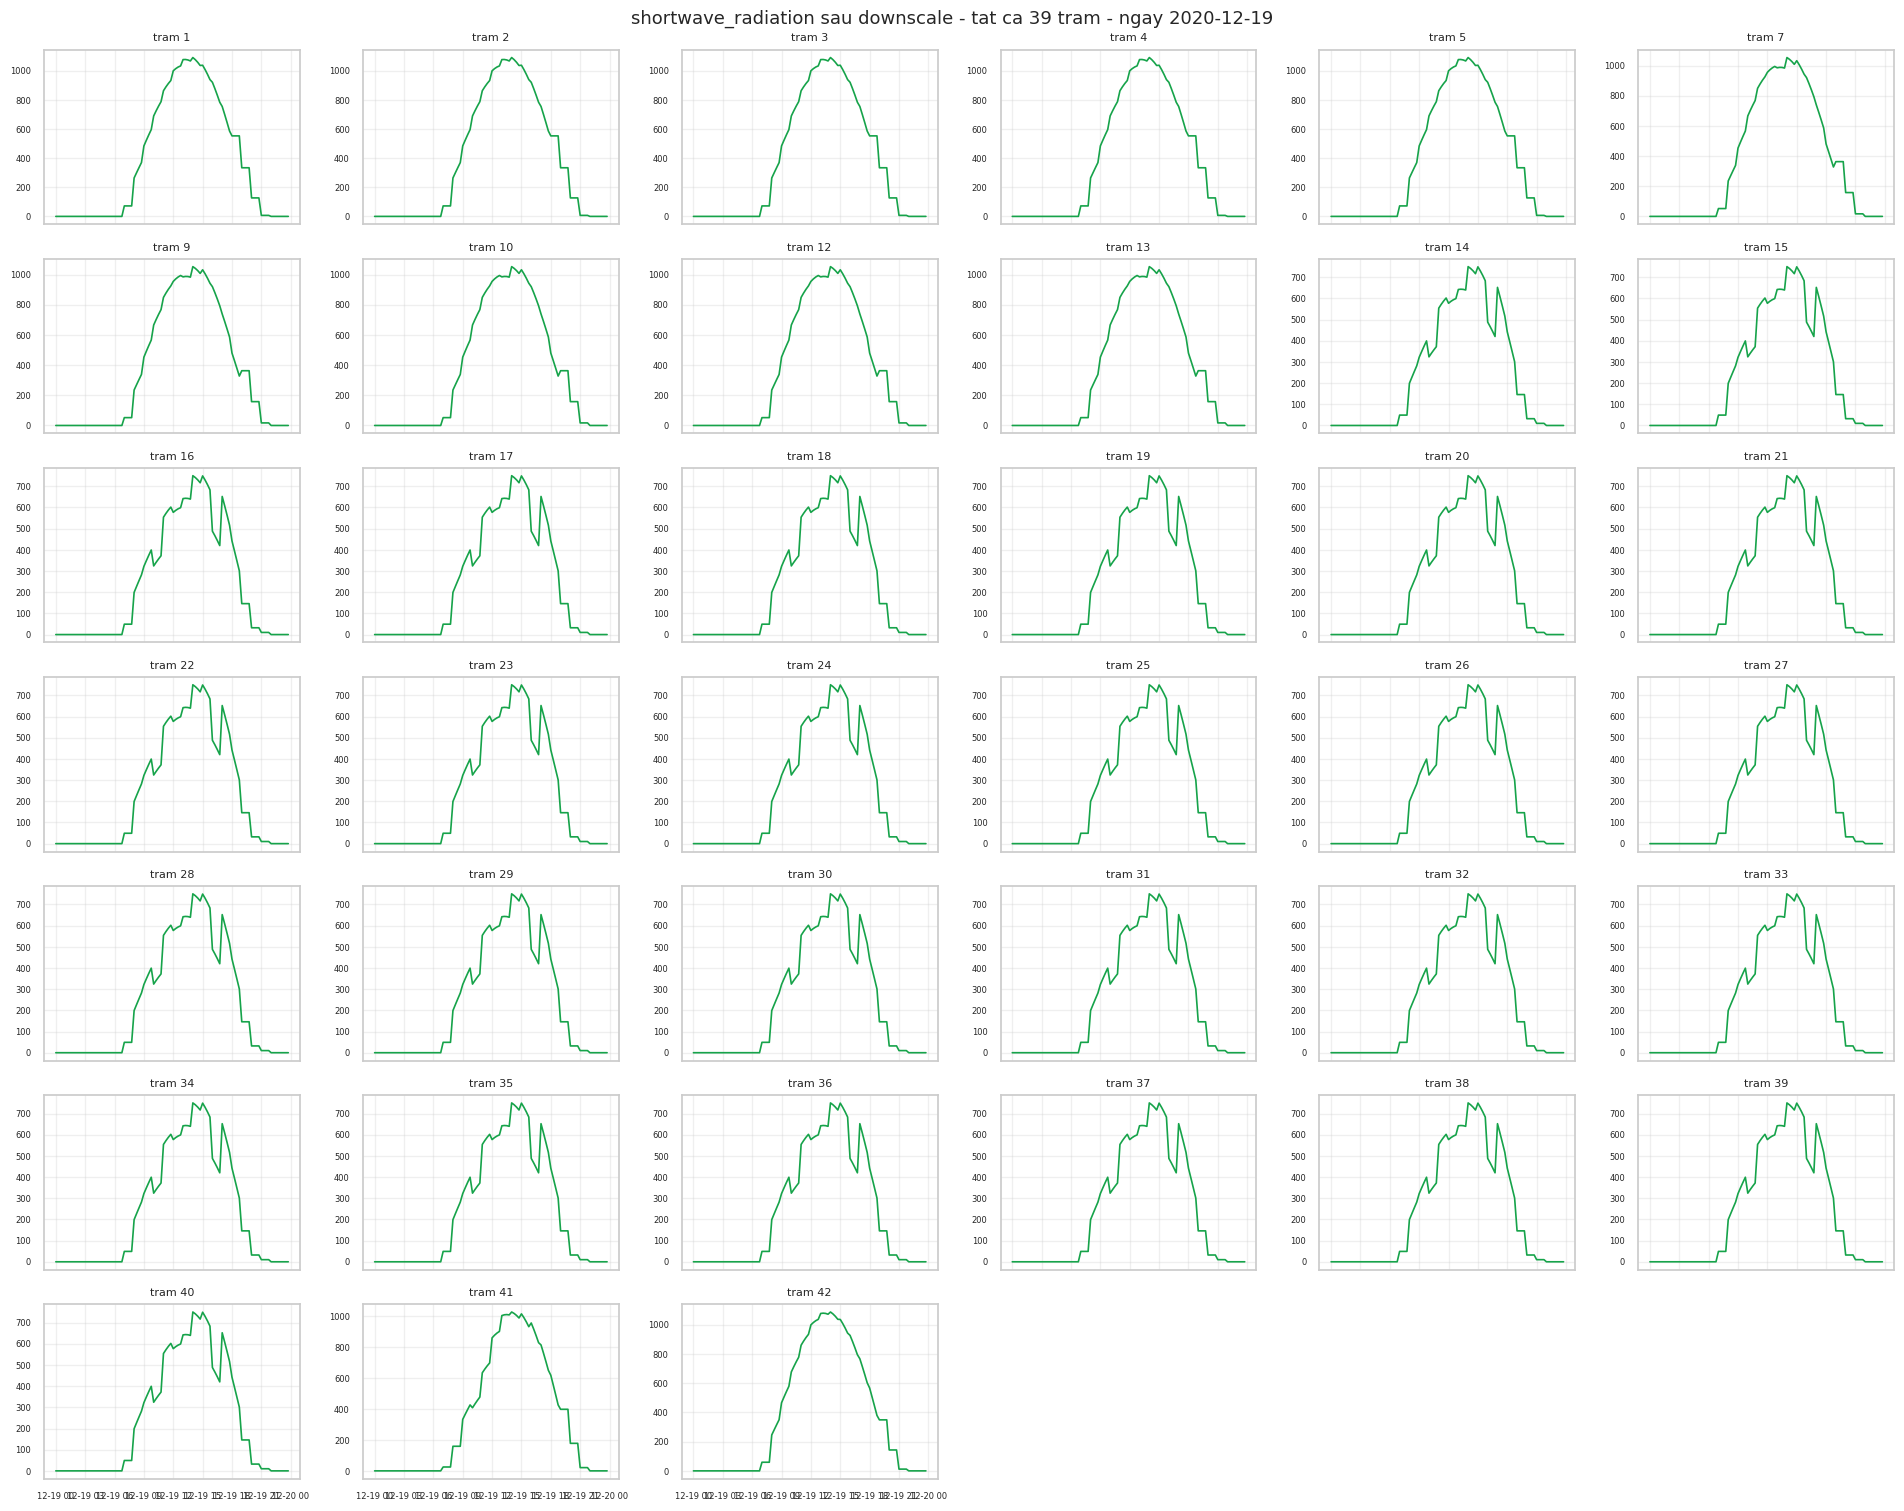

Da ve 39 tram cho ngay 2020-12-19.
Doi mat tim: dinh nhon dot bien, bac thang con sot, hoac gia tri am.


6146

In [13]:
_full = pd.read_parquet(f'{OUTPUT_DIR}/{VERSION}_train_spatial.parquet',
                        columns=[SITE_COL, TIMESTAMP_COL, 'shortwave_radiation'])
_full['ngay'] = _full[TIMESTAMP_COL].dt.date
_ngay_chung = _full[_full[SITE_COL] == _full[SITE_COL].iloc[0]].groupby('ngay')['shortwave_radiation'].sum().idxmax()
_d = _full[_full['ngay'] == _ngay_chung].sort_values([SITE_COL, TIMESTAMP_COL])

_sites = sorted(_d[SITE_COL].unique())
_ncol = 6
_nrow = int(np.ceil(len(_sites) / _ncol))
fig, axes = plt.subplots(_nrow, _ncol, figsize=(3.2 * _ncol, 2.2 * _nrow), sharex=True)
axes = axes.flatten()
for ax, s in zip(axes, _sites):
    x = _d[_d[SITE_COL] == s]
    ax.plot(x[TIMESTAMP_COL], x['shortwave_radiation'], lw=1.2, color='#16a34a')
    ax.set_title(f'tram {s}', fontsize=8)
    ax.tick_params(labelsize=6)
    ax.grid(alpha=0.3)
for ax in axes[len(_sites):]:
    ax.axis('off')
fig.suptitle(f'shortwave_radiation sau downscale - tat ca {len(_sites)} tram - ngay {_ngay_chung}', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Da ve {len(_sites)} tram cho ngay {_ngay_chung}.")
print("Doi mat tim: dinh nhon dot bien, bac thang con sot, hoac gia tri am.")
del _full, _d
gc.collect()


## Bước 7.3. Trực quan hoá quy mô và trần công suất từng trạm

Hai việc cần thấy:

1. So `tran_cong_suat` tính từ dữ liệu với trần vật lý suy từ `capacity_kw` — trạm nào vượt là metadata sai
2. Phân bố `ty_le_bao_hoa` — gần 1 nghĩa là trạm thường xuyên chạm trần inverter


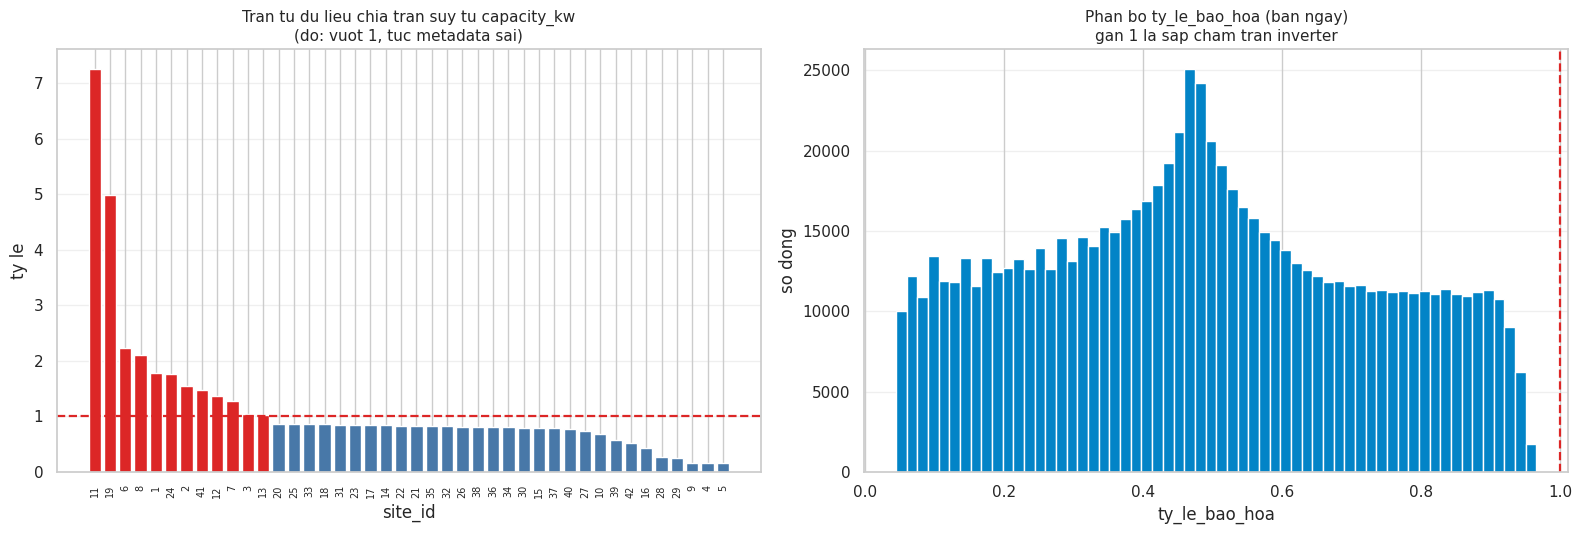

--- TRAM CO METADATA capacity_kw SAI (ty le > 1) ---


,cap_kw,tran_du_lieu,quy_mo,tran_vat_ly,ty_le
site_id,,,,,
11,51.15,92.660004,91.410004,12.79,7.25
19,34.32,42.820000,41.680000,8.58,4.99
6,51.15,28.490000,27.160000,12.79,2.23
8,51.15,26.860001,26.320000,12.79,2.10
1,51.15,22.750000,21.469999,12.79,1.78
24,40.26,17.760000,17.610001,10.06,1.76
2,51.15,19.730000,18.459999,12.79,1.54
41,51.15,18.750000,18.190001,12.79,1.47
12,51.15,17.530001,16.809999,12.79,1.37


So tram vuot tran vat ly: 12/42


27

In [14]:
_tr = pd.read_parquet(f'{OUTPUT_DIR}/{VERSION}_train_spatial.parquet',
                      columns=[SITE_COL, TARGET_COL, 'capacity_kw', 'tran_cong_suat',
                               'site_scale', 'ty_le_bao_hoa', 'sin_elevation'])
_g = _tr.groupby(SITE_COL).agg(
    cap_kw=('capacity_kw', 'first'),
    tran_du_lieu=('tran_cong_suat', 'first'),
    quy_mo=('site_scale', 'first'),
)
_g['tran_vat_ly'] = _g['cap_kw'] * 0.25          # kWh toi da trong 15 phut
_g['ty_le'] = (_g['tran_du_lieu'] / _g['tran_vat_ly']).round(2)
_g = _g.sort_values('ty_le', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
_c = ['#dc2626' if v > 1 else '#4878a8' for v in _g['ty_le']]
axes[0].bar(_g.index.astype(str), _g['ty_le'], color=_c)
axes[0].axhline(1.0, color='#dc2626', ls='--', lw=1.6)
axes[0].set_title("Tran tu du lieu chia tran suy tu capacity_kw\n(do: vuot 1, tuc metadata sai)", fontsize=11)
axes[0].set_xlabel('site_id')
axes[0].set_ylabel('ty le')
axes[0].tick_params(axis='x', labelsize=7, rotation=90)
axes[0].grid(alpha=0.3, axis='y')

_bn = _tr[_tr['sin_elevation'] > EPS_ELEV]
axes[1].hist(_bn['ty_le_bao_hoa'].dropna(), bins=60, color='#0284c7')
axes[1].axvline(1.0, color='#dc2626', ls='--', lw=1.6)
axes[1].set_title("Phan bo ty_le_bao_hoa (ban ngay)\ngan 1 la sap cham tran inverter", fontsize=11)
axes[1].set_xlabel('ty_le_bao_hoa')
axes[1].set_ylabel('so dong')
axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("--- TRAM CO METADATA capacity_kw SAI (ty le > 1) ---")
display(_g[_g['ty_le'] > 1].round(2))
print(f"So tram vuot tran vat ly: {(_g['ty_le'] > 1).sum()}/{len(_g)}")
del _tr, _bn
gc.collect()


### Nhận xét về quy mô trạm

Trạm nào có tỉ lệ vượt 1 thì `capacity_kw` trong metadata không dùng được, phải dựa vào `site_scale`
và `tran_cong_suat` tính từ dữ liệu. Đó là lý do hai cột này được thêm vào đây thay vì dùng `capacity_kw`
trực tiếp.


## Bước 7. Phân tích & Trực quan hóa Đặc trưng Metadata (Spatial Features)

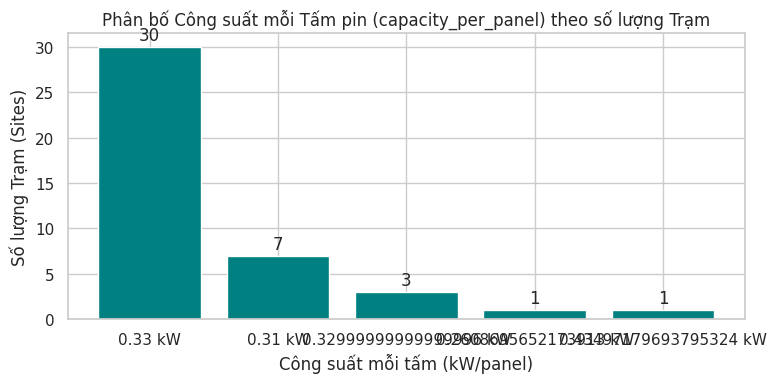

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_spatial = read_parquet(f'{OUTPUT_DIR}/{VERSION}_train_spatial.parquet')

if 'capacity_per_panel' in df_spatial.columns:
    cap_counts = df_spatial.groupby('site_id')['capacity_per_panel'].first().value_counts().reset_index()
    cap_counts.columns = ['capacity_per_panel', 'num_sites']
    
    plt.figure(figsize=(8, 4))
    bars = plt.bar(cap_counts['capacity_per_panel'].astype(str) + ' kW', cap_counts['num_sites'], color='teal')
    plt.title("Phân bố Công suất mỗi Tấm pin (capacity_per_panel) theo số lượng Trạm")
    plt.xlabel("Công suất mỗi tấm (kW/panel)")
    plt.ylabel("Số lượng Trạm (Sites)")
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.3, int(yval), ha='center', va='bottom')
    plt.tight_layout()
    plt.show()

### Nhận xét về Đặc trưng Spatial (Metadata):
- Đặc trưng `capacity_per_panel` chỉ có 4 giá trị rời rạc gần như hằng số trên toàn hệ thống (33 trạm có giá trị ~0.330 kW, 7 trạm có giá trị ~0.310 kW, 1 trạm 0.435 kW, 1 trạm 0.261 kW).
- Việc mã hóa các thuộc tính phân loại (`site_id_enc`, `campus_name_enc`) được thực hiện đồng bộ ở bước 03-3 để đảm bảo fit mã hóa trên tập train mà không gây rò rỉ dữ liệu.

## Bước 8. Hoàn tất

In [16]:
print("Hoàn tất bước 03-2: Đặc trưng metadata trạm.")

Hoàn tất bước 03-2: Đặc trưng metadata trạm.
